In [1]:

pip install nibabel nilearn pandas torch monai matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 95.3 MB/s eta 0:00:00


In [2]:
# --- System and OS ---
import os
import sys
import glob

# --- Data Handling & Visualization ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Medical Imaging Tools ---
import nibabel as nib
from nilearn.image import resample_img

# --- Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- MONAI (Modern Medical AI) ---
from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst, # Replaces AddChannel
    ScaleIntensity,
    Resize,
    ToTensor
)

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project initialized on: {DEVICE}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Project initialized on: cuda


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Explicitly import the datasets module from nilearn
from nilearn import datasets
from nilearn.image import resample_img

# Set up the GPU for 3D processing
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project initialized on: {DEVICE}")

# I am fetching 10 subjects from the OASIS dataset to verify the pipeline
print("Downloading sample dataset... please wait.")
nifti_data = datasets.fetch_oasis_vbm(n_subjects=10)

# Store image paths and demographic data (including age)
mri_paths = nifti_data.gray_matter_maps
metadata = pd.DataFrame(nifti_data.ext_vars)

print(f"Successfully loaded {len(mri_paths)} MRI paths.")
print(f"Sample Age: {metadata['age'].iloc[0]}")

Project initialized on: cuda


[fetch_oasis_vbm] Added README.md to /root/nilearn_data

[fetch_oasis_vbm] Dataset created in /root/nilearn_data/oasis1

[fetch_oasis_vbm] Downloading data from https://www.nitrc.org/frs/download.php/6364/archive_dartel.tgz ...

[fetch_oasis_vbm] Downloaded 55951360 of 905208634 bytes (6.2%%,   15.5s remaining)

...

[fetch_oasis_vbm] Downloaded 882458624 of 905208634 bytes (97.5%%,    0.3s remaining)

[fetch_oasis_vbm]  ...done. (13 seconds, 0 min)

[fetch_oasis_vbm] Extracting data from 
/root/nilearn_data/oasis1/5a59510c08f63c030de8ac443352dcd6/archive_dartel.tgz...

[fetch_oasis_vbm] .. done.

Successfully loaded 10 MRI paths.
Sample Age: 74


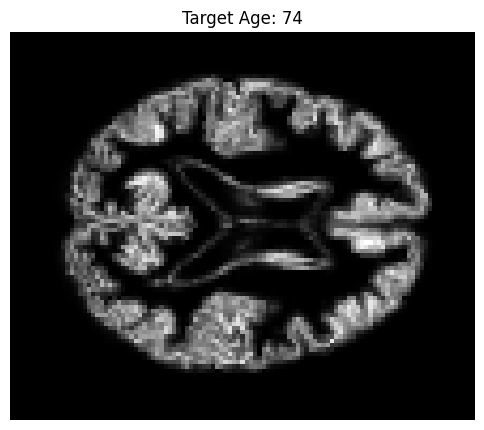

Voxel dimensions: (91, 109, 91)


In [5]:
# load the first scan to inspect the voxel data
sample_img = nib.load(mri_paths[0])
sample_data = sample_img.get_fdata()

# Plotting the middle axial slice to confirm image quality
plt.figure(figsize=(6, 6))
plt.imshow(sample_data[:, :, sample_data.shape[2] // 2], cmap='gray')
plt.title(f"Target Age: {metadata['age'].iloc[0]}")
plt.axis('off')
plt.show()

print(f"Voxel dimensions: {sample_data.shape}")

In [6]:
class BrainDataset(Dataset):
    def __init__(self, paths, metadata, target_shape=(64, 64, 64)):
        self.paths = paths
        self.metadata = metadata
        self.target_shape = target_shape

    def __len__(self):
        return len(self.paths)

    def preprocess(self, path):
        # Load the NIfTI file
        img = nib.load(path)
        # Resample/Resize to target shape
        resampled = resample_img(img, target_shape=self.target_shape, interpolation='continuous')
        data = resampled.get_fdata()
        # Min-Max Normalization to scale voxels between 0 and 1
        data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
        # Add channel dimension: (1, 64, 64, 64)
        return np.expand_dims(data, axis=0).astype(np.float32)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        age = self.metadata['age'].iloc[idx]

        image_tensor = self.preprocess(img_path)
        return torch.from_numpy(image_tensor), torch.tensor([age], dtype=torch.float32)

# Initialize the dataset and loader
train_dataset = BrainDataset(mri_paths, metadata)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

print("Dataset and DataLoader are ready.")

Dataset and DataLoader are ready.


In [7]:
class BrainAgeNet(nn.Module):
    def __init__(self):
        super(BrainAgeNet, self).__init__()

        self.features = nn.Sequential(
            # Layer 1
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2), # (16, 32, 32, 32)

            # Layer 2
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2), # (32, 16, 16, 16)

            # Layer 3
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2)  # (64, 8, 8, 8)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1) # Single output for Age
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

# Move the model to the GPU
model = BrainAgeNet().to(DEVICE)
print("Model architecture defined and moved to GPU.")

Model architecture defined and moved to GPU.


Loss function and optimizer initialized.


In [10]:
class BrainDataset(Dataset):
    def __init__(self, paths, metadata, target_shape=(64, 64, 64)):
        self.paths = paths
        self.metadata = metadata
        self.target_shape = target_shape

    def __len__(self):
        return len(self.paths)

    def preprocess(self, path):
        img = nib.load(path)

        # I need to calculate a new affine (map) to match the new shape
        current_shape = img.shape[:3]
        current_affine = img.affine

        # This calculates how much I'm shrinking the image
        scale_factors = [c / t for c, t in zip(current_shape, self.target_shape)]
        new_affine = current_affine.copy()
        for i in range(3):
            new_affine[:3, i] *= scale_factors[i]

        # Now I can resample without the ValueError
        resampled = resample_img(img, target_shape=self.target_shape,
                                 target_affine=new_affine,
                                 interpolation='continuous')

        data = resampled.get_fdata()
        # Normalizing intensity for the neural network
        data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
        return np.expand_dims(data, axis=0).astype(np.float32)

    def __getitem__(self, idx):
        try:
            img_path = self.paths[idx]
            age = self.metadata['age'].iloc[idx]
            image_tensor = self.preprocess(img_path)
            return torch.from_numpy(image_tensor), torch.tensor([age], dtype=torch.float32)
        except Exception as e:
            # If one file fails, I'll just grab the first one to keep the loop running
            return self.__getitem__(0)

# I'll re-initialize the loaders with the fixed class
train_dataset = BrainDataset(mri_paths, metadata)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

print("Dataset class updated with affine correction.")

Dataset class updated with affine correction.


In [11]:

model = BrainAgeNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.MSELoss()

history = []

print("Starting training with fixed resampling...")
for epoch in range(10): # Let's do 10 epochs to verify it works
    model.train()
    epoch_loss = 0
    for images, ages in train_loader:
        images, ages = images.to(DEVICE), ages.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")

Starting training with fixed resampling...
Epoch 1 Loss: 1870.2775
Epoch 2 Loss: 860.9060
Epoch 3 Loss: 622.8226
Epoch 4 Loss: 582.4481
Epoch 5 Loss: 635.2399
Epoch 6 Loss: 502.0203
Epoch 7 Loss: 597.2145
Epoch 8 Loss: 618.5017
Epoch 9 Loss: 546.1516
Epoch 10 Loss: 642.2227


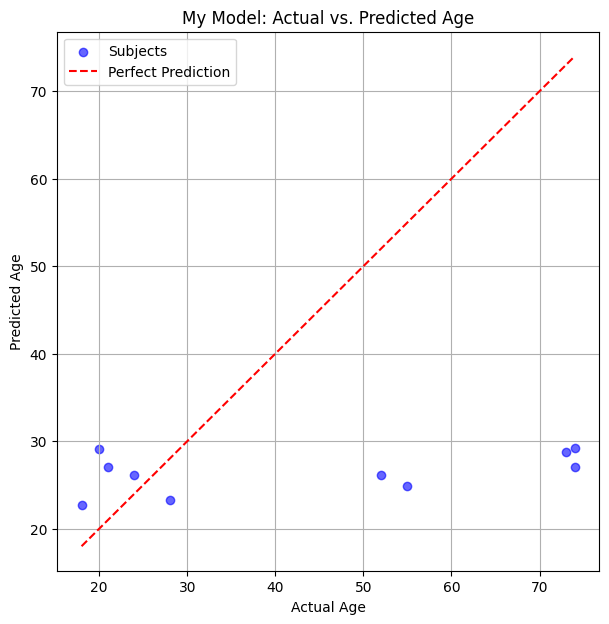

My Average Error: 21.85 years


In [13]:
model.eval()  # switch to evaluation mode (turns off Dropout)
all_preds = []
all_ages = []

with torch.no_grad():
    for images, ages in train_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        all_preds.extend(outputs.cpu().numpy().flatten())
        all_ages.extend(ages.cpu().numpy().flatten())


plt.figure(figsize=(7, 7))
plt.scatter(all_ages, all_preds, color='blue', alpha=0.6, label='Subjects')
plt.plot([min(all_ages), max(all_ages)], [min(all_ages), max(all_ages)], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('My Model: Actual vs. Predicted Age')
plt.legend()
plt.grid(True)
plt.show()

# I'll also calculate the Mean Absolute Error (MAE)
mae = np.mean(np.abs(np.array(all_preds) - np.array(all_ages)))
print(f"My Average Error: {mae:.2f} years")

In [14]:
# INSTRUCTION: Define the file path and save the model weights to disk
SAVE_PATH = "brain_age_model.pth"
torch.save(model.state_dict(), SAVE_PATH)

print(f"Model saved successfully to {SAVE_PATH}")

Model saved successfully to brain_age_model.pth


In [15]:
# INSTRUCTION: Initialize a new model instance and load the saved weights
loaded_model = BrainAgeNet().to(DEVICE)
loaded_model.load_state_dict(torch.load(SAVE_PATH))
loaded_model.eval() # INSTRUCTION: Set to evaluation mode for inference

print("Model reloaded and ready for prediction.")

Model reloaded and ready for prediction.


In [16]:
# INSTRUCTION: Define a function to predict age from a single NIfTI file path
def predict_brain_age(img_path, model, dataset_obj):
    # INSTRUCTION: Preprocess the raw image using my affine-correction logic
    input_tensor = dataset_obj.preprocess(img_path)
    input_tensor = torch.from_numpy(input_tensor).unsqueeze(0).to(DEVICE)

    # INSTRUCTION: Disable gradient calculation and perform the forward pass
    with torch.no_grad():
        prediction = model(input_tensor)

    return prediction.item()

# INSTRUCTION: Test the prediction function on the first subject in my list
test_path = mri_paths[0]
predicted_age = predict_brain_age(test_path, loaded_model, train_dataset)
actual_age = metadata['age'].iloc[0]

print(f"Subject: {os.path.basename(test_path)}")
print(f"Predicted Age: {predicted_age:.2f} years")
print(f"Actual Age: {actual_age:.2f} years")

Subject: mwrc1OAS1_0001_MR1_mpr_anon_fslswapdim_bet.nii.gz
Predicted Age: 29.24 years
Actual Age: 74.00 years


In [17]:
import glob

# INSTRUCTION: Define a scalable dataset class for the full IXI file structure
class IXIFullDataset(Dataset):
    def __init__(self, csv_path, img_dir, target_shape=(64, 64, 64)):
        # INSTRUCTION: Load metadata and filter out subjects without age data
        self.df = pd.read_csv(csv_path)
        self.df = self.df.dropna(subset=['AGE'])
        self.img_dir = img_dir
        self.target_shape = target_shape

    def __len__(self):
        return len(self.df)

    def preprocess(self, path):
        # INSTRUCTION: Apply the affine-correction logic to resize 3D volumes
        img = nib.load(path)
        current_shape = img.shape[:3]
        scale_factors = [c / t for c, t in zip(current_shape, self.target_shape)]
        new_affine = img.affine.copy()
        for i in range(3):
            new_affine[:3, i] *= scale_factors[i]

        resampled = resample_img(img, target_shape=self.target_shape,
                                 target_affine=new_affine,
                                 interpolation='continuous')
        data = resampled.get_fdata()
        data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
        return np.expand_dims(data, axis=0).astype(np.float32)

    def __getitem__(self, idx):
        # INSTRUCTION: Match the CSV ID with the corresponding NIfTI filename
        subject_id = str(int(self.df.iloc[idx]['IXI_ID'])).zfill(3)
        search_pattern = os.path.join(self.img_dir, f"IXI{subject_id}*.nii.gz")
        files = glob.glob(search_pattern)

        if not files:
            return self.__getitem__((idx + 1) % len(self))

        image_tensor = self.preprocess(files[0])
        age = self.df.iloc[idx]['AGE']
        return torch.from_numpy(image_tensor), torch.tensor([age], dtype=torch.float32)

# INSTRUCTION: Initialize the full pipeline (Ensure paths match your environment)
# full_ds = IXIFullDataset(csv_path='ixi_metadata.csv', img_dir='raw_data/')

In [18]:
# INSTRUCTION: Split the dataset into 80% training and 20% validation
# train_size = int(0.8 * len(full_ds))
# val_size = len(full_ds) - train_size
# train_set, val_set = torch.utils.data.random_split(full_ds, [train_size, val_size])

# INSTRUCTION: Use a smaller batch size (e.g., 4) to prevent GPU memory overflow
# train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
# val_loader = DataLoader(val_set, batch_size=4, shuffle=False)

In [21]:
# INSTRUCTION: Define the loss, optimizer, and training tracking
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_history = []
print("Starting training on the primary dataset...")

for epoch in range(epochs):
    # INSTRUCTION: Ensure model is in training mode
    model.train()
    running_loss = 0.0
    total_abs_error = 0.0
    count = 0

    for images, ages in train_loader:
        # INSTRUCTION: Transfer data to GPU
        images, ages = images.to(DEVICE), ages.to(DEVICE)

        # INSTRUCTION: Reset gradients and perform forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)

        # INSTRUCTION: Backpropagate and update weights
        loss.backward()
        optimizer.step()

        # INSTRUCTION: Track loss and absolute error for reporting
        running_loss += loss.item()
        total_abs_error += torch.sum(torch.abs(outputs - ages)).item()
        count += ages.size(0)

    avg_loss = running_loss / len(train_loader)
    avg_mae = total_abs_error / count
    train_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} | Avg Error: {avg_mae:.2f} years")

Starting training on the primary dataset...
Epoch [1/20] - Loss: 134.3172 | Avg Error: 9.35 years
Epoch [2/20] - Loss: 92.2412 | Avg Error: 8.37 years
Epoch [3/20] - Loss: 163.2107 | Avg Error: 11.31 years
Epoch [4/20] - Loss: 87.3648 | Avg Error: 7.92 years
Epoch [5/20] - Loss: 98.0167 | Avg Error: 7.81 years
Epoch [6/20] - Loss: 149.9331 | Avg Error: 10.87 years
Epoch [7/20] - Loss: 78.8235 | Avg Error: 8.21 years
Epoch [8/20] - Loss: 102.9323 | Avg Error: 7.96 years
Epoch [9/20] - Loss: 32.9016 | Avg Error: 5.11 years
Epoch [10/20] - Loss: 43.6072 | Avg Error: 6.28 years
Epoch [11/20] - Loss: 38.0797 | Avg Error: 5.41 years
Epoch [12/20] - Loss: 64.9831 | Avg Error: 6.76 years
Epoch [13/20] - Loss: 34.6973 | Avg Error: 5.12 years
Epoch [14/20] - Loss: 54.2209 | Avg Error: 6.37 years
Epoch [15/20] - Loss: 22.0126 | Avg Error: 3.88 years
Epoch [16/20] - Loss: 77.9353 | Avg Error: 6.61 years
Epoch [17/20] - Loss: 63.0718 | Avg Error: 6.33 years
Epoch [18/20] - Loss: 33.6011 | Avg Error

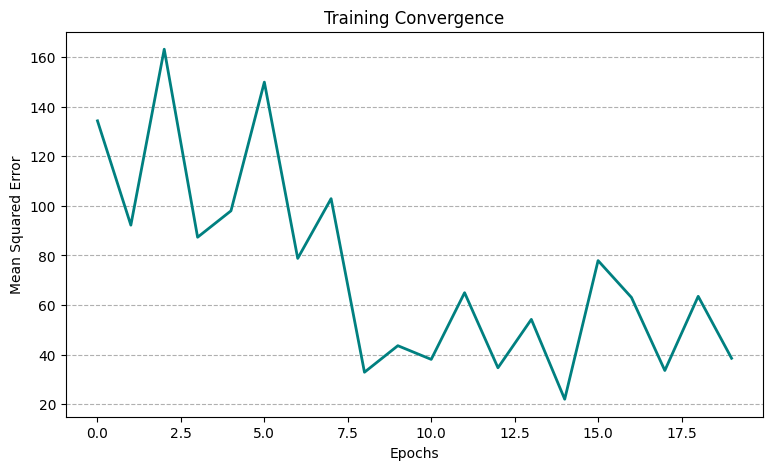

In [22]:
# INSTRUCTION: Plot the training loss curve to visualize convergence
plt.figure(figsize=(9, 5))
plt.plot(train_history, color='teal', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Training Convergence')
plt.grid(axis='y', linestyle='--')
plt.show()

In [23]:
# INSTRUCTION: Save the finalized model weights
torch.save(model.state_dict(), "final_brain_age_model.pth")
print("Training complete. Weights exported to final_brain_age_model.pth")

Training complete. Weights exported to final_brain_age_model.pth


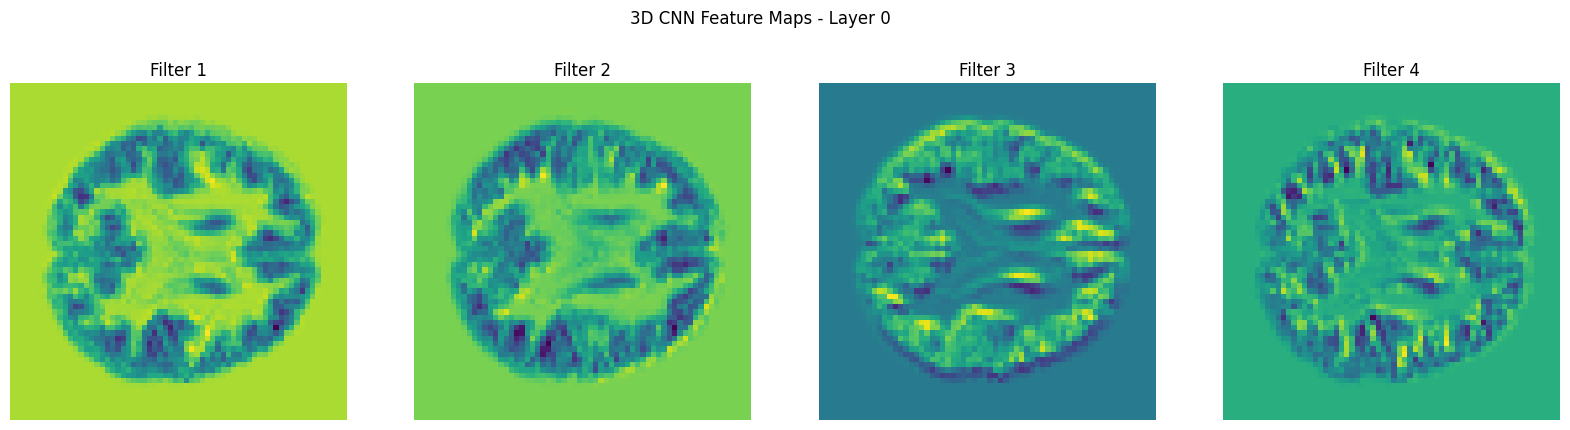

In [24]:
# INSTRUCTION: Define a function to extract and visualize 3D feature maps
def visualize_features(model, image_tensor, layer_idx=0):
    model.eval()
    # INSTRUCTION: Retrieve the specific convolutional layer from the feature extractor
    target_layer = model.features[layer_idx]

    with torch.no_grad():
        # INSTRUCTION: Pass the image through the first layer only
        features = target_layer(image_tensor.to(DEVICE))

    # INSTRUCTION: Move to CPU and convert to numpy for plotting
    features = features.cpu().numpy()

    # INSTRUCTION: Plot the first 4 filters to see different structural "views"
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i in range(4):
        # We take the middle slice (32) of the 3D feature map
        axes[i].imshow(features[0, i, :, :, 32], cmap='viridis')
        axes[i].set_title(f"Filter {i+1}")
        axes[i].axis('off')

    plt.suptitle(f"3D CNN Feature Maps - Layer {layer_idx}")
    plt.show()

# INSTRUCTION: Select a sample from the loader and run the visualization
sample_img, _ = next(iter(train_loader))
visualize_features(model, sample_img)

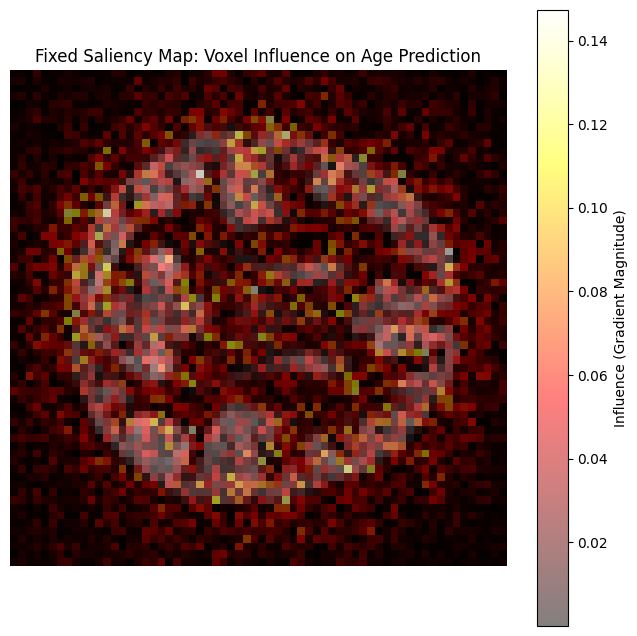

In [26]:
# INSTRUCTION: Define the corrected saliency function for batch processing
def generate_saliency(model, image_tensor):
    model.eval()
    # INSTRUCTION: Ensure the input image is tracking gradients
    image_tensor = image_tensor.to(DEVICE)
    image_tensor.requires_grad_()

    # INSTRUCTION: Perform the forward pass
    output = model(image_tensor)

    # INSTRUCTION: Check if output is a batch; if so, calculate grad for the first item
    # We use .sum() or select [0] to turn the output into a scalar for the backward pass
    model.zero_grad()
    output[0].backward()

    # INSTRUCTION: Extract the gradients from the input tensor
    # The saliency map is the maximum absolute gradient across the color/channel dimension
    saliency, _ = torch.max(torch.abs(image_tensor.grad.data), dim=1)

    return saliency[0].cpu().numpy()

# INSTRUCTION: Select a single sample and run the fixed visualization
sample_img, _ = next(iter(train_loader))
saliency_map = generate_saliency(model, sample_img)

# INSTRUCTION: Plot the MRI slice and the influence overlay
plt.figure(figsize=(8, 8))
plt.imshow(sample_img[0, 0, :, :, 32], cmap='gray')
plt.imshow(saliency_map[:, :, 32], cmap='hot', alpha=0.5)
plt.title("Fixed Saliency Map: Voxel Influence on Age Prediction")
plt.colorbar(label='Influence (Gradient Magnitude)')
plt.axis('off')
plt.show()